In [52]:
import numpy as np
import pymaster as nmt
import matplotlib.pyplot as plt

In [66]:
# Load residuals

nside = 64
lmax = 2*nside-1
lbin = 35
Nlbin = 10

if lbin is None:
    b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=True) # Binning scheme for the cross-spectra
else:
    ell_ini = np.concatenate((np.arange(2, lbin), np.arange(lbin, 3*nside, Nlbin)))
    ell_end = np.concatenate((np.arange(2, lbin)+1, np.arange(lbin, 3*nside, Nlbin)+Nlbin))
    ell_end = ell_end[ell_end <= 3*nside]
    ell_ini = ell_ini[:len(ell_end)]
    b = nmt.NmtBin.from_edges(ell_ini, ell_end, is_Dell=True)
    b.lmax = 3*nside-1

leff = b.get_effective_ells()
leff = leff[leff + (Nlbin+1)/2 <= lmax]
Nbins = len(leff)

DLcross = np.load('/pscratch/sd/s/svinzl/B_modes_project/power_spectra/DLcross_nside64_fsky0.5_P_402_10deg_baseline_scale10_Nlbin10_lbin35_dbsbc_gaussbeam_bandpass_FM_B.npy')[:, :, :Nbins]
N, Ncross, Nbins = DLcross.shape

data = np.zeros((N, Ncross*Nbins))
for i in range(N):
    data[i] = np.concatenate(DLcross[i].T)

covmat_sims = np.cov(data.T)
covmat_basis = np.load('/pscratch/sd/s/svinzl/B_modes_project/covariances/cov_Nmt-fg_nside64_fsky0.5_P_402_10deg_baseline_scale10_Nlbin10_lbin35_dbsbc_gaussbeam_bandpass_FM.npy')[:Ncross*Nbins, :Ncross*Nbins]
covmat_new = np.load('/pscratch/sd/s/svinzl/B_modes_project/covariances/cov_Nmt-fg_nside64_fsky0.5_P_402_10deg_baseline_scale10_Nlbin10_lbin35_dbsbc_gaussbeam_bandpass_FM_B.npy')[:Ncross*Nbins, :Ncross*Nbins]

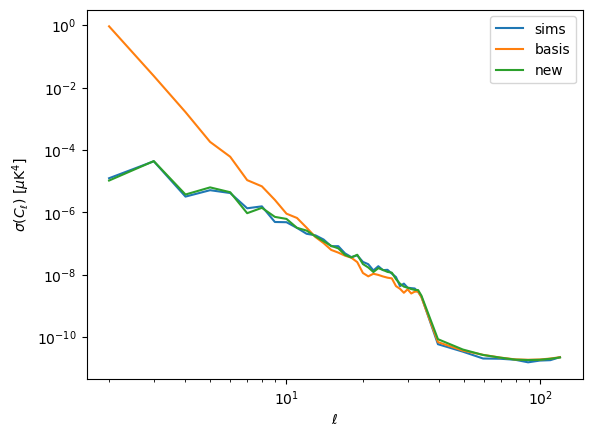

In [67]:
id_cross = 23
idx = id_cross + Ncross*np.arange(Nbins)

sigma_sims = np.diag(covmat_sims)[idx] * (1 / leff / (leff+1) * 2*np.pi)**2
sigma_basis = np.diag(covmat_basis)[idx] * (1 / leff / (leff+1) * 2*np.pi)**2
sigma_new = np.diag(covmat_new)[idx] * (1 / leff / (leff+1) * 2*np.pi)**2

plt.plot(leff, sigma_sims, label='sims')
plt.plot(leff, sigma_basis, label='basis')
plt.plot(leff, sigma_new, label='new')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\sigma(C_\ell)$ [$\mu$K$^4$]')
plt.legend()
plt.show()